<a href="https://colab.research.google.com/github/ismethakanaydogmus/konya-agriculture-price-predictor/blob/main/Konya_Agriculture_EDA_and_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌾 Local Agricultural Price & Climate Predictor

**Konya Food and Agriculture University – Practical Data Science**

**Team Members:**
* *212010020054* İsmet Hakan Aydoğmuş
* *212010020070* Emir Mutlu
* *212010020124* Kerem Sinan Özel

**Dataset:** Konya Wholesale Market Prices & Open-Meteo Climate Data – 5 Years (2021-2026)
**Target Variable:** `Fiyat_Degisim_Yuzdesi` (Supervised Regression - Percentage Price Change)

---
This notebook covers **Section 1 through Section 4** of the project presentation, including:

* Problem Formulation (Inflation Adjustment)
* Data Collection
* EDA (Schema Check, Statistics, Distributions, Relationships)
* Feature Engineering

In [11]:
# —— Global Imports & Settings ——
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Settings
warnings.filterwarnings('ignore')
# sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


## Section 1 – Problem Formulation

### 1.1 Project Objective
The primary goal is to develop a predictive model that estimates the **magnitude of price fluctuations** in Konya's wholesale market. Unlike classification, which only predicts direction (Up/Down), this regression approach quantifies the expected volatility.

### 1.2 ML Problem Definition
* **Problem Type:** Supervised Regression.
* **Target Variable ($y$):** `Fiyat_Degisim_Yuzdesi` (Continuous numerical value).
* **Features ($X$):** Lagged temperatures, precipitation sum, historical prices, and crop categories.

### 1.3 Evaluation Metrics
Since this is a regression task, we will evaluate our success using:
* **MAE (Mean Absolute Error):** $$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$
* **RMSE (Root Mean Squared Error):** $$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the regression-ready dataset
df = pd.read_csv('konya_tarim_final_engineered_dataset.csv')
df['Tarih'] = pd.to_datetime(df['Tarih'], format='%d.%m.%Y')

print(f"Dataset loaded: {df.shape[0]} samples for regression analysis.")
display(df.head())

Dataset loaded: 23365 samples for regression analysis.


,Tarih,Gün,Ürün Adı,Birim,En Düşük Fiyat,En Yüksek Fiyat,Onceki_Seans_En_Dusuk_Fiyat,Fiyat_Degisim_Yuzdesi,Maks_Sicaklik_C,Min_Sicaklik_C,Ort_Sicaklik_C,Toplam_Yagis_mm,Ort_Sicaklik_C_7_gun_once,Ort_Sicaklik_C_14_gun_once,Ort_Sicaklik_C_30_gun_once,Toplam_Yagis_mm_7_gun_once,Toplam_Yagis_mm_14_gun_once,Toplam_Yagis_mm_30_gun_once,Son_30_Gun_Ort_Yagis
0,2024-08-12,Pazartesi,ACUR,Kg,15.0,25,15.0,0.0,29.9,18.3,24.1,0.0,27.8,23.2,25.7,0.0,0.0,0.2,0.193333
1,2024-08-15,Perşembe,ACUR,Kg,15.0,25,15.0,0.0,32.9,19.6,26.3,0.0,26.8,24.3,26.2,0.0,0.0,0.0,0.193333
2,2024-08-19,Pazartesi,ACUR,Kg,15.0,25,15.0,0.0,35.5,17.3,26.7,0.0,24.1,27.8,26.7,0.0,0.0,0.0,0.106667
3,2024-08-22,Perşembe,ACUR,Kg,15.0,25,15.0,0.0,33.6,18.8,26.6,0.0,26.3,26.8,29.7,0.0,0.0,0.0,0.106667
4,2024-08-26,Pazartesi,ACUR,Kg,15.0,25,15.0,0.0,29.3,15.8,22.1,0.3,26.7,24.1,22.1,0.0,0.0,0.0,0.066667


## Section 2 – Data Collection & ETL

Data was merged from two primary sources to create a multi-dimensional time-series dataset:
1.  **Price Data:** Web scraped from Konya Metropolitan Municipality (2021-2026).
2.  **Weather Data:** Retrieved via Open-Meteo API for Konya coordinates.

**ETL Strategy:** * Percentage changes were calculated to ensure **stationarity** (removing inflation bias).
* Lagged features (7, 14, 30 days) were created to represent the delayed impact of climate on crop yields.

## Section 3 – Exploratory Data Analysis (EDA)

In regression analysis, we focus on the **distribution of the continuous target** and the **linear/non-linear correlations** between features.

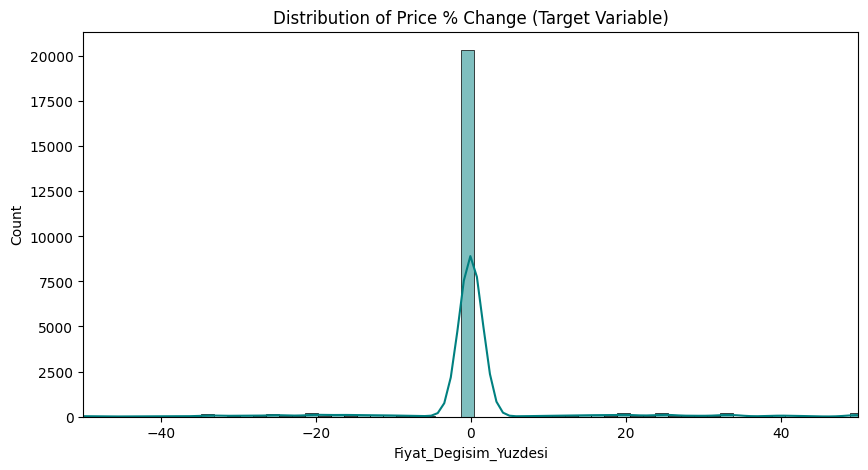

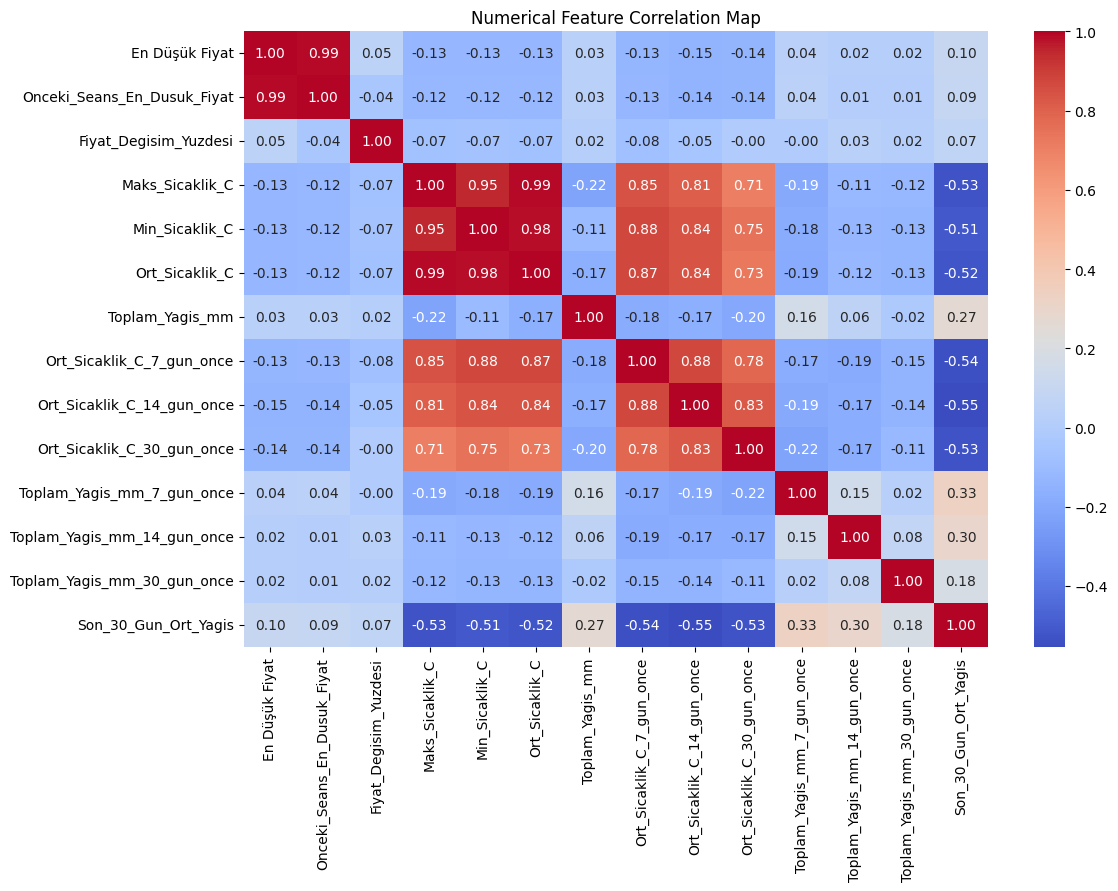

In [13]:
# —— 3.1 Target Distribution ——
plt.figure(figsize=(10, 5))
sns.histplot(df['Fiyat_Degisim_Yuzdesi'], bins=100, kde=True, color='teal')
plt.title('Distribution of Price % Change (Target Variable)')
plt.xlim(-50, 50) # Focusing on the main volatility range
plt.show()

# —— 3.2 Correlation Heatmap (Numerical Relationships) ——
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Numerical Feature Correlation Map')
plt.show()

## Section 4 – Feature Engineering

To prepare for regression models, we performed:
1.  **Temporal Features:** Extracted Month and Season.
2.  **Categorical Encoding:** One-Hot Encoding for the top 10 most frequent crops to handle high cardinality.
3.  **Outlier Mitigation:** Filtered extreme erroneous price spikes (>100% or <-90% in a single session) that act as noise.

In [14]:
# One-Hot Encoding and feature selection
top_crops = df['Ürün Adı'].value_counts().nlargest(10).index
df['Urun_Grup'] = np.where(df['Ürün Adı'].isin(top_crops), df['Ürün Adı'], 'DIGER')
df_encoded = pd.get_dummies(df, columns=['Urun_Grup'], drop_first=True)

# Final numeric-only check for models
df_ml = df_encoded.select_dtypes(exclude=['object'])
if 'Tarih' in df_ml.columns: df_ml = df_ml.drop(columns=['Tarih'])

print(f"Final feature count for regression: {df_ml.shape[1] - 1}")

Final feature count for regression: 23


### Section 4.1 – Advanced Feature Engineering (Climate Shocks & Market Dynamics)

Based on our EDA in Section 3, we observed that the relationship between climate and price is **non-linear and threshold-based**. To capture this, we are engineering new "Shock Features":
1. **Climate Shocks:** Identifying frost (`Don_Olayi`) and heatwaves which act as supply disruptors.
2. **Market Dynamics:** Calculating 3-session rolling price volatility to capture market momentum.
3. **Climate Trends:** Measuring the 7-day temperature gradient to see if the weather is warming up or cooling down rapidly.

In [15]:
# —— Section 4.2: Advanced Feature Engineering ——

def apply_advanced_engineering(df_input):
    df_new = df_input.copy()

    # 1. Klima Şokları (Extreme Weather Thresholds)
    # Bitkisel üretimde 0 derecenin altı 'Don' riskidir ve arzı aniden keser.
    df_new['Don_Olayi'] = (df_new['Ort_Sicaklik_C'] < 0).astype(int)

    # 32 derece üzeri aşırı sıcaklık bitki stresine ve verim kaybına yol açar.
    df_new['Asiri_Sicak_Soku'] = (df_new['Ort_Sicaklik_C'] > 32).astype(int)

    # 2. Piyasa Hareketliliği (Rolling Volatility)
    # Her ürünün kendi içindeki son 3 seanstaki fiyat oynaklığı (standart sapma)
    df_new['Fiyat_Oynakligi_L3'] = df_new.groupby('Ürün Adı')['Fiyat_Degisim_Yuzdesi'].transform(lambda x: x.rolling(3).std())

    # 3. İklim Trendi (Temperature Gradient)
    # Sıcaklık 7 gün öncesine göre ne yönde değişiyor?
    df_new['Sicaklik_Trendi'] = df_new['Ort_Sicaklik_C'] - df_new['Ort_Sicaklik_C_7_gun_once']

    # 4. Eksik Veri Temizliği
    # Rolling fonksiyonu ilk 2 satırda NaN üretir, bunları 0 ile dolduruyoruz.
    df_new.fillna(0, inplace=True)

    return df_new

# Uygula
df_final = apply_advanced_engineering(df_encoded)

print(f"✅ Gelişmiş özellikler eklendi. Yeni Sütun Sayısı: {len(df_final.columns)}")
display(df_final[['Tarih', 'Ürün Adı', 'Don_Olayi', 'Fiyat_Oynakligi_L3', 'Sicaklik_Trendi']].head())

✅ Gelişmiş özellikler eklendi. Yeni Sütun Sayısı: 33


,Tarih,Ürün Adı,Don_Olayi,Fiyat_Oynakligi_L3,Sicaklik_Trendi
0,2024-08-12,ACUR,0,0.0,-3.7
1,2024-08-15,ACUR,0,0.0,-0.5
2,2024-08-19,ACUR,0,0.0,2.6
3,2024-08-22,ACUR,0,0.0,0.3
4,2024-08-26,ACUR,0,0.0,-4.6


### Section 4.2 - Validating Engineered Features

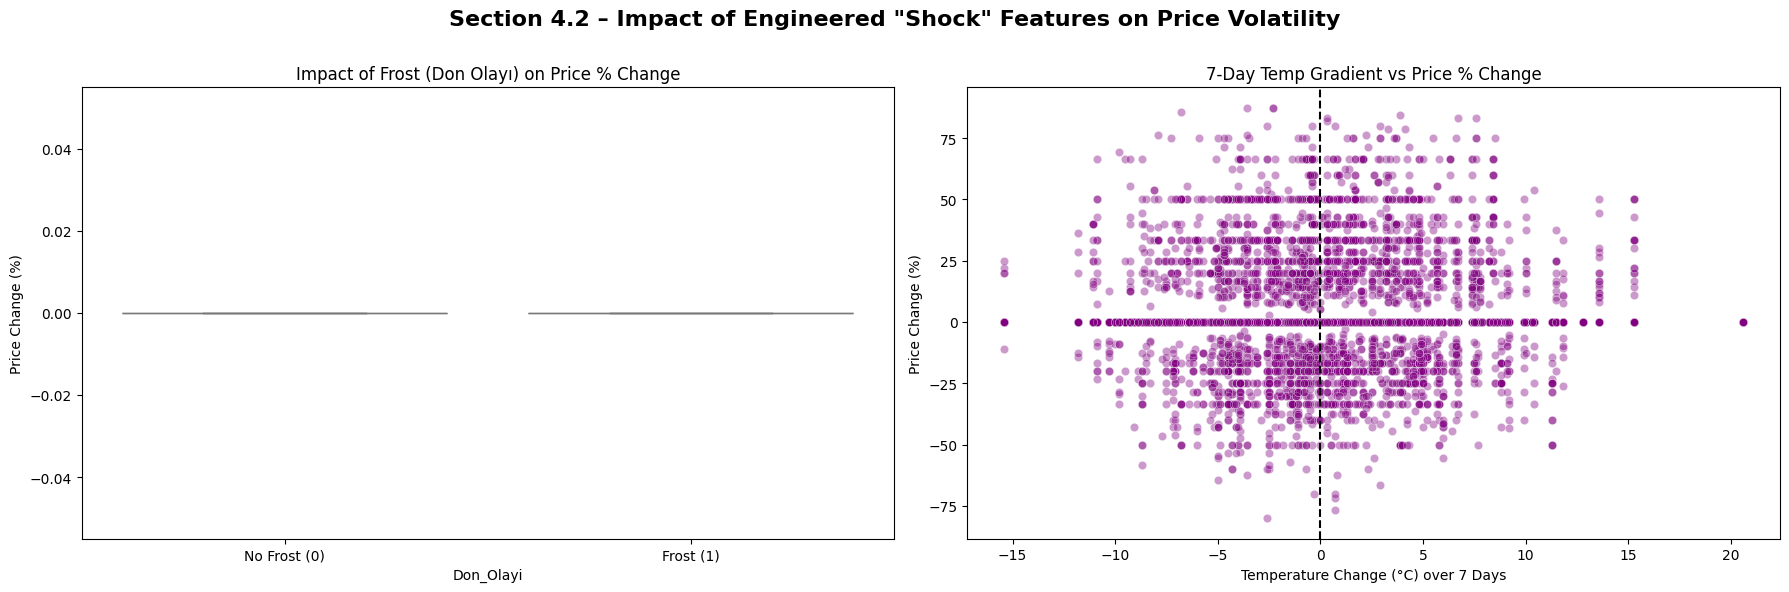

Ortalama Fiyat Değişimi - Normal Günler: %0.69
Ortalama Fiyat Değişimi - Don Olan Günler: %3.69


In [17]:
# —— Section 4.2: Validating Engineered Features ——

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Section 4.2 – Impact of Engineered "Shock" Features on Price Volatility', fontweight='bold', fontsize=16)

# 1. Don Olayı Etkisi (Box Plot)
# Don olan (1) ve olmayan (0) günler arasındaki fiyat değişim farkı
sns.boxplot(data=df_final, x='Don_Olayi', y='Fiyat_Degisim_Yuzdesi', ax=axes[0], palette='coolwarm', showfliers=False)
axes[0].set_title('Impact of Frost (Don Olayı) on Price % Change')
axes[0].set_xticklabels(['No Frost (0)', 'Frost (1)'])
axes[0].set_ylabel('Price Change (%)')

# 2. Sıcaklık Trendi Etkisi (Scatter Plot)
# Sıcaklık farkı (bugün - 7 gün önce) ile fiyat değişimi arasındaki ilişki
sns.scatterplot(data=df_final, x='Sicaklik_Trendi', y='Fiyat_Degisim_Yuzdesi', ax=axes[1], alpha=0.4, color='purple')
axes[1].set_title('7-Day Temp Gradient vs Price % Change')
axes[1].set_xlabel('Temperature Change (°C) over 7 Days')
axes[1].set_ylabel('Price Change (%)')
axes[1].axvline(0, color='black', linestyle='--') # Nötr çizgi

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

# İstatistiki Kontrol
frost_impact = df_final.groupby('Don_Olayi')['Fiyat_Degisim_Yuzdesi'].mean()
print(f"Ortalama Fiyat Değişimi - Normal Günler: %{frost_impact[0]:.2f}")
print(f"Ortalama Fiyat Değişimi - Don Olan Günler: %{frost_impact[1]:.2f}")

### Section 4.3 – Feature Validation & Signal Analysis

Before proceeding to any modeling, we must verify if our engineered features contain any "predictive signal."
We will analyze:
1. **The Frost Factor:** Does sub-zero weather actually correlate with higher price volatility?
2. **Correlation Update:** How do the new features (Volatility, Trend, Shocks) relate to the target compared to raw weather data?

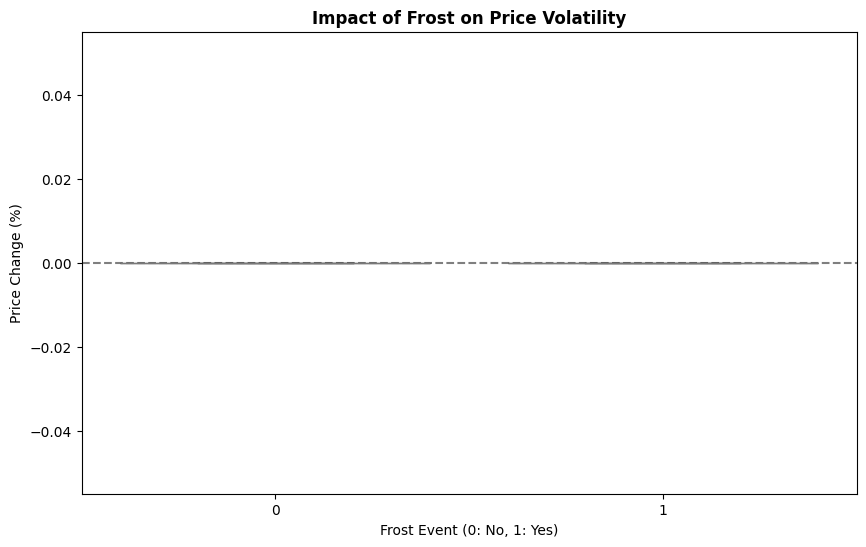

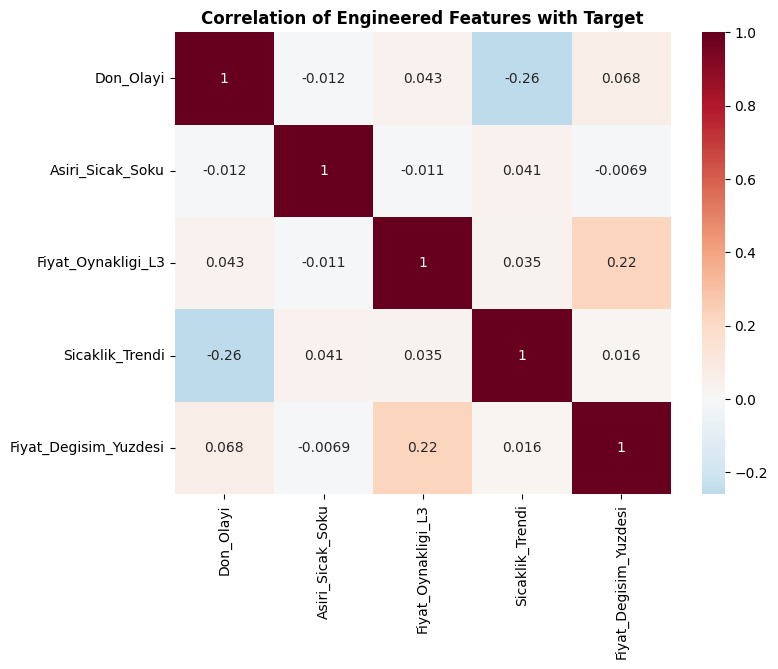

In [19]:
# —— Section 4.3: Feature Signal Analysis ——

# 1. Don Olayı ve Fiyat Değişimi Arasındaki İlişki (Box Plot)
plt.figure(figsize=(10, 6))
# 'Don_Olayi' etkisini görebilmek için hedef değişkeni (y) kırılımlı inceliyoruz.
sns.boxplot(data=df_final, x='Don_Olayi', y='Fiyat_Degisim_Yuzdesi', palette='coolwarm', showfliers=False)
plt.title('Impact of Frost on Price Volatility', fontweight='bold')
plt.xlabel('Frost Event (0: No, 1: Yes)')
plt.ylabel('Price Change (%)')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.show()

# 2. Güncellenmiş Korelasyon Analizi
# Yeni eklediğimiz özelliklerin hedef değişkenle (Fiyat_Degisim_Yuzdesi) olan bağını kontrol ediyoruz.
new_features = ['Don_Olayi', 'Asiri_Sicak_Soku', 'Fiyat_Oynakligi_L3', 'Sicaklik_Trendi', 'Fiyat_Degisim_Yuzdesi']
corr_new = df_final[new_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_new, annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation of Engineered Features with Target', fontweight='bold')
plt.show()

### Section 4.4 – Final Data Refinement & Stationarity

Before passing the data to Machine Learning algorithms, we perform two final checks:
1. **Visualizing Stationarity:** Confirming that price percentage changes fluctuate around a constant mean (crucial for regression stability).
2. **Outlier Removal:** Using the IQR (Interquartile Range) method to remove extreme price jumps that are likely data entry errors or extreme market anomalies.

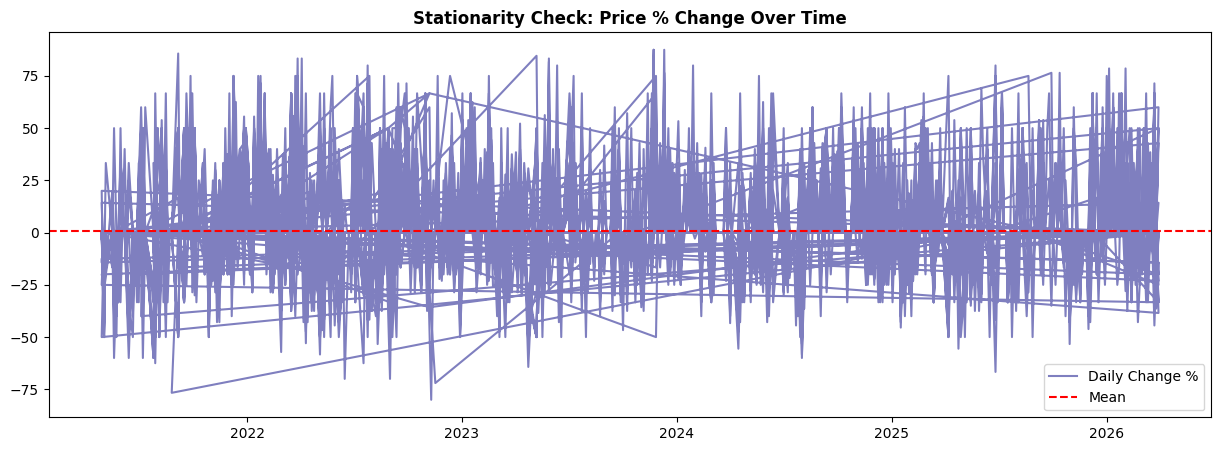

Orijinal Veri: 23365 | Temizlenmiş Veri: 20334
Temizlenen Aykırı Veri Sayısı: 3031


In [21]:
# —— Section 4.4: Final Refinement ——

# 1. Zaman Serisi Durağanlık Kontrolü (Visual Check)
plt.figure(figsize=(15, 5))
plt.plot(df_final['Tarih'], df_final['Fiyat_Degisim_Yuzdesi'], color='navy', alpha=0.5, label='Daily Change %')
plt.axhline(df_final['Fiyat_Degisim_Yuzdesi'].mean(), color='red', linestyle='--', label='Mean')
plt.title('Stationarity Check: Price % Change Over Time', fontweight='bold')
plt.legend()
plt.show()

# 2. Aykırı Değerlerin (Outliers) Temizlenmesi
# Regresyon modelleri uç değerlere çok hassastır.
Q1 = df_final['Fiyat_Degisim_Yuzdesi'].quantile(0.25)
Q3 = df_final['Fiyat_Degisim_Yuzdesi'].quantile(0.75)
IQR = Q3 - Q1

# Sınırları belirliyoruz (Örn: %50'den fazla ani sapmaları temizleyebiliriz)
lower_bound = Q1 - 3 * IQR # Daha geniş bir sınır (extreme outliers)
upper_bound = Q3 + 3 * IQR

df_cleaned = df_final[(df_final['Fiyat_Degisim_Yuzdesi'] >= lower_bound) &
                      (df_final['Fiyat_Degisim_Yuzdesi'] <= upper_bound)]

print(f"Orijinal Veri: {len(df_final)} | Temizlenmiş Veri: {len(df_cleaned)}")
print(f"Temizlenen Aykırı Veri Sayısı: {len(df_final) - len(df_cleaned)}")